# CAPSTONE PROJECT : MONEY-TOR [DATA SCIENCE]
- CDCC325D6Y0761 - Ignatius William Alvin
- CDCC325D6Y2656 - Jason Nathannael

# A/B Testing: Pengaruh Promosi terhadap Nilai Transaksi UMKM

## Tujuan

Analisis ini bertujuan untuk mengetahui apakah promosi yang diberikan pada event tertentu memberikan pengaruh signifikan terhadap nilai transaksi UMKM.

Kelompok yang dibandingkan:

- Group A : Transaksi tanpa promosi (Tanpa Promo)
- Group B : Transaksi dengan promosi (Promo)

Metrik yang digunakan adalah total nilai transaksi (`total_harga`).


## Hal yang diuji adalah:
  1. Pembagian kelompok transaksi promo dan tanpa promo
  2. Statistik deskriptif masing-masing kelompok
  3. Pengujian hipotesis menggunakan Welch's Independent T-Test
  4. Pengambilan keputusan berdasarkan p-value
  5. Interpretasi hasil dan kesimpulan bisnis

## Import Library & Load Dataset

In [22]:
# Import Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load Dataset
main_data = pd.read_csv('main_data_featured.csv')

In [23]:
# Melihat pembagian kelompok dari kolom status promo
main_data['status_promo'].value_counts()

,count
status_promo,
Tanpa Promo,26357
Promo,3643


## Hipotesis

- H0 (Null Hypothesis)
  
  Tidak terdapat perbedaan rata-rata nilai transaksi antara transaksi yang menggunakan promosi dan transaksi tanpa promosi.

- H1 (Alternative Hypothesis)

  Terdapat perbedaan rata-rata nilai transaksi antara transaksi yang menggunakan promosi dan transaksi tanpa promosi.

In [24]:
# Membuat Group A & Group B
#    Pada tahap ini data transaksi dibagi menjadi dua kelompok berdasarkan fitur
#    status_promo. Kelompok A terdiri dari transaksi tanpa promosi (Tanpa Promo),
#    sedangkan Kelompok B terdiri dari transaksi yang menggunakan promosi (Promo).
#    Pembagian ini dilakukan untuk membentuk kelompok pembanding dalam pengujian
#    A/B Testing.

tanpa_promo = main_data[
    main_data['status_promo'] == 'Tanpa Promo'
]['total_harga']

promo = main_data[
    main_data['status_promo'] == 'Promo'
]['total_harga']


In [25]:
# Analisis Statistik Deskriptif
#     Pada tahap ini dilakukan perhitungan statistik deskriptif untuk masing-masing
#     kelompok, seperti jumlah data, rata-rata, median, standar deviasi, nilai
#     minimum, dan nilai maksimum. Tujuannya adalah untuk memperoleh gambaran awal
#     mengenai karakteristik nilai transaksi pada kedua kelompok sebelum dilakukan
#     pengujian statistik.

print("Tanpa Promo")
print(tanpa_promo.describe())

print("\n")

print("Promo")
print(promo.describe())

Tanpa Promo
count     26357.000000
mean      75067.325568
std       72309.761723
min        4000.000000
25%       30000.000000
50%       56000.000000
75%       90000.000000
max      700000.000000
Name: total_harga, dtype: float64


Promo
count      3643.000000
mean      72150.192149
std       71654.745324
min        4000.000000
25%       28500.000000
50%       54000.000000
75%       90000.000000
max      700000.000000
Name: total_harga, dtype: float64


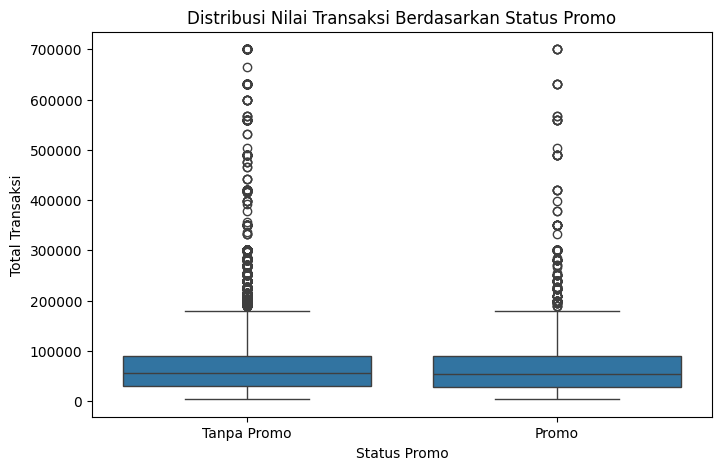

In [26]:
# Menampilkan Visualisasi Distirbusi
plt.figure(figsize=(8,5))

sns.boxplot(
    data=main_data,
    x='status_promo',
    y='total_harga'
)

plt.title('Distribusi Nilai Transaksi Berdasarkan Status Promo')
plt.xlabel('Status Promo')
plt.ylabel('Total Transaksi')

plt.show()

## Tingkat Signifikansi

Pada pengujian ini digunakan tingkat signifikansi (α) sebesar 0,05. Jika nilai p-value lebih kecil dari α, maka H0 ditolak dan H1 diterima.

In [27]:
# Melakukan T-test
#    Pada tahap ini dilakukan pengujian statistik menggunakan Welch's Independent
#    T-Test untuk membandingkan rata-rata nilai transaksi antara kelompok promo dan
#    tanpa promo. Metode ini dipilih karena ukuran sampel kedua kelompok tidak
#    seimbang sehingga lebih sesuai dibandingkan T-Test standar.

t_stat, p_value = ttest_ind(
    promo,
    tanpa_promo,
    equal_var=False
)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : -2.300618070485915
P-Value : 0.021456563861859693


In [28]:
# Pengambilan Keputusan Hipotesis
#    Pada tahap akhir dilakukan interpretasi terhadap hasil pengujian statistik
#    untuk menghasilkan insight bisnis. Hasil analisis digunakan untuk mengevaluasi
#    efektivitas promosi terhadap nilai transaksi UMKM dan memberikan rekomendasi
#    yang dapat mendukung pengambilan keputusan bisnis.

alpha = 0.05

if p_value < alpha:
    print("Tolak H0")
    print("Terdapat perbedaan signifikan antara transaksi promo dan tanpa promo.")
else:
    print("Gagal menolak H0")
    print("Tidak terdapat perbedaan signifikan antara transaksi promo dan tanpa promo.")

Tolak H0
Terdapat perbedaan signifikan antara transaksi promo dan tanpa promo.


## KESIMPULAN

Berdasarkan hasil Welch's Independent T-Test, diperoleh nilai p-value sebesar 0,0215, yang lebih kecil dari tingkat signifikansi 0,05. Oleh karena itu, hipotesis nol (H0) ditolak, sehingga dapat disimpulkan bahwa terdapat perbedaan yang signifikan antara nilai transaksi yang menggunakan promosi dan transaksi tanpa promosi. Meskipun demikian, rata-rata nilai transaksi tanpa promosi (Rp75.067) sedikit lebih tinggi dibandingkan rata-rata nilai transaksi promosi (Rp72.150). Temuan ini menunjukkan bahwa promosi memiliki pengaruh terhadap transaksi yang terjadi, namun belum tentu mampu meningkatkan nilai transaksi per pembelian. Oleh karena itu, UMKM perlu mengevaluasi strategi promosi yang diterapkan agar tidak hanya menarik pelanggan, tetapi juga mampu meningkatkan nilai transaksi dan pendapatan secara lebih optimal.